# Abhishek Kothari
# Assignment 2B

Part 5

In [1]:
import pandas as pd
from collections import deque
import matplotlib.pyplot as plt
import numpy as np
from sklearn.datasets import make_circles, make_moons, make_blobs
from sklearn.metrics import pairwise_distances, silhouette_score
from sklearn.preprocessing import StandardScaler

In [6]:
df = pd.read_csv("dbscan.csv")

In [8]:
df.head()

,cluster,pt,x,y,num_neighbors,neighbors
0,NaN,0,51.418089,13.593610,2,"0,27"
1,NaN,1,39.132318,-4.419204,3,"1,40,75"
2,NaN,2,47.807515,-25.822561,1,2
3,NaN,3,27.699703,53.434193,1,3
4,NaN,4,39.860995,5.676871,3,"4,56,75"


In [10]:
# lets assign every point as an outlier to begin with and then we will put them in diff clusters
df['cluster'] = -1

In [12]:
epsilon = 7.5
min_pts = 3
current_cluster = 0

In [18]:
def create_clusters(point,cluster):
    queue = deque([point])
    df.at[point,'cluster'] = cluster

    while queue:
        current_point = queue.popleft()
        neighbors = df.at[current_point,'neighbors']
        neighbors = [int(n) for n in neighbors.split(',')] if isinstance(neighbors, str) else []

        if len(neighbors)>=min_pts:
            for neighbor in neighbors:
                if df.at[neighbor,'cluster'] == -1:
                    df.at[neighbor,'cluster'] = cluster
                    queue.append(neighbor)        

In [20]:
for index,row in df.iterrows():
    if df.at[index,'cluster'] != -1:
        continue
    if row['num_neighbors']< min_pts:
        df.at[index,'cluster'] = -1
    else:
        current_cluster += 1
        create_clusters(index,current_cluster)

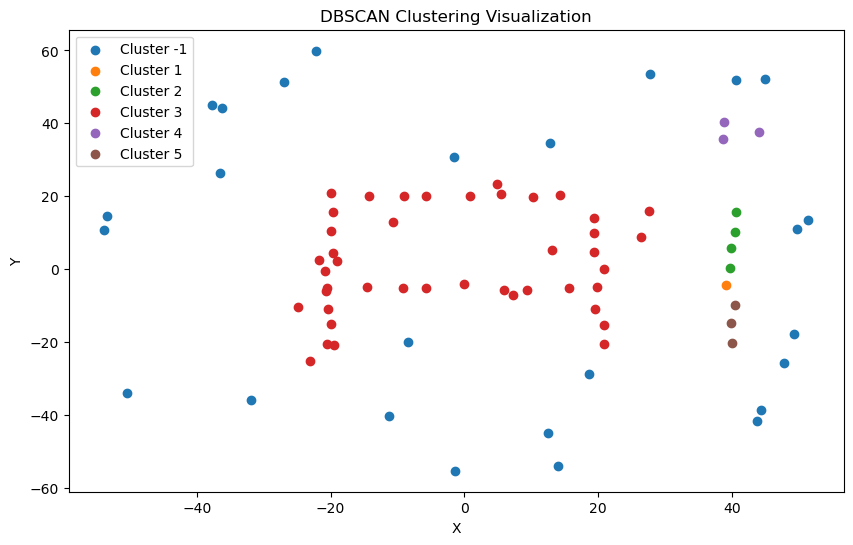

In [26]:
plt.figure(figsize=(10,6))
for cluster_id in df["cluster"].unique():
    cluster_points = df[df["cluster"] == cluster_id]
    plt.scatter(cluster_points["x"], cluster_points["y"], label=f"Cluster {cluster_id}")

plt.xlabel("X")
plt.ylabel("Y")
plt.legend()
plt.title("DBSCAN Clustering Visualization")
plt.show()

Problem 6

In [4]:
from sklearn.datasets import make_circles, make_moons, make_blobs
from sklearn.metrics import pairwise_distances, silhouette_score

In [4]:
class DBSCAN:
    def __init__(self, eps = 0.3, min_pts = 3):
        self.eps = eps
        self.min_pts = min_pts
        self.labels = None
    def fit(self,X):
        n = X.shape[0]
        self.labels = np.full(n,-1)
        cluster_id = 0
        distances = pairwise_distances(X,metric = 'euclidean')
        for i in range(n):
            if self.labels[i] != -1:
                continue
            neighbors = np.where(distances[i]< self.eps)[0]
            if len(neighbors) < self.min_pts:
                self.labels[i] = 0
            else:
                cluster_id += 1
                self.expand_cluster(X, i, neighbors, cluster_id, distances)
    def expand_cluster(self, X, point_idx, neighbors, cluster_id, distances):
        self.labels[point_idx] = cluster_id
        queue = list(neighbors)

        while queue:
            current_point = queue.pop(0)
            if self.labels[current_point] == 0:  # if previously marked as noise, convert to border point
                self.labels[current_point] = cluster_id

            if self.labels[current_point] != -1:  # skip already classified points
                continue
            
            self.labels[current_point] = cluster_id  # assign cluster
            new_neighbors = np.where(distances[current_point] < self.eps)[0]

            if len(new_neighbors) >= self.min_pts:
                queue.extend(new_neighbors)  

In [167]:
circles = pd.read_csv('circle.csv')
blobs = pd.read_csv('blobs.csv')
moons = pd.read_csv('moons.csv')

In [169]:
circles.head()

,Xcircle_X1,Xcircle_X2
0,0.519781,-0.015981
1,-0.057719,-0.420279
2,-0.805155,-0.662227
3,0.316549,0.312730
4,-0.304804,0.407563


In [171]:
blobs.head()

,Xblobs_X1,Xblobs_X2
0,1.684922,0.683154
1,-0.669550,-1.023103
2,-0.816166,-0.887977
3,1.188173,1.124579
4,1.179278,1.678473


In [173]:
moons.head()

,Xmoons_X1,Xmoons_X2
0,-0.378142,0.940750
1,0.933566,0.153805
2,2.048309,0.498172
3,0.947891,0.162473
4,2.000739,0.183700


In [175]:
data = {
    'Circles': circles if isinstance(circles, pd.DataFrame) else pd.DataFrame(circles),
    'Blobs': blobs if isinstance(blobs, pd.DataFrame) else pd.DataFrame(blobs),
    'Moons': moons if isinstance(moons, pd.DataFrame) else pd.DataFrame(moons),
}

In [177]:
eps = 0.3
min_pts = 5

In [179]:
def extract_features(df):
    return df[[col for col in df.columns if '_X' in col or '_x' in col or '_X1' in col]].values

In [6]:
from sklearn.preprocessing import StandardScaler

In [12]:
def run_dbscan(dataset_name, df, eps, min_pts):
    X = extract_features(df)  
    X_scaled = StandardScaler().fit_transform(X)
    model = DBSCAN(eps=eps, min_pts=min_pts)  
    model.fit(X_scaled)
    labels = model.labels

    # count clusters and noise points
    num_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    num_noise = np.sum(labels == -1)

    print(f"\n--- {dataset_name} ---")
    print(f"Total Clusters: {num_clusters}")
    print(f"Total Noise Points: {num_noise}")

    if num_clusters > 1:
        score = silhouette_score(X_scaled, labels)
        print(f"Silhouette Score: {score:.4f}")
    else:
        print("Silhouette Score: N/A (only one cluster detected)")

    plt.figure(figsize=(6, 5))
    plt.scatter(X[:, 0], X[:, 1], c=labels, cmap="viridis", edgecolors="k", s=50)
    plt.title(f"DBSCAN Clustering - {dataset_name}")
    plt.xlabel(df.columns[0])
    plt.ylabel(df.columns[1])
    plt.show()


--- Circles ---
Total Clusters: 2
Total Noise Points: 0
Silhouette Score: 0.1134


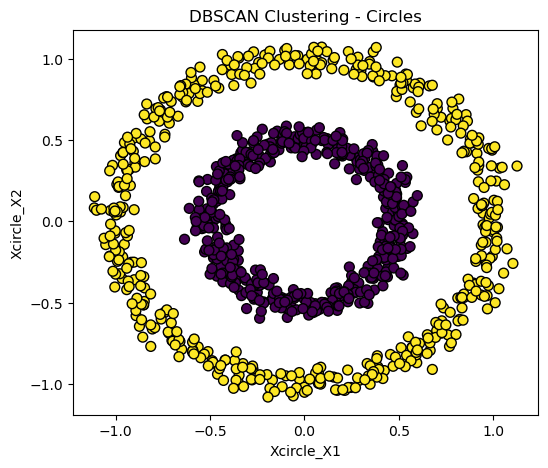


--- Blobs ---
Total Clusters: 3
Total Noise Points: 0
Silhouette Score: 0.5338


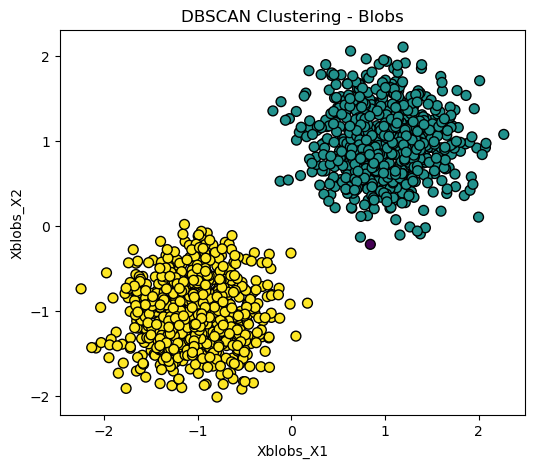


--- Moons ---
Total Clusters: 2
Total Noise Points: 0
Silhouette Score: 0.3922


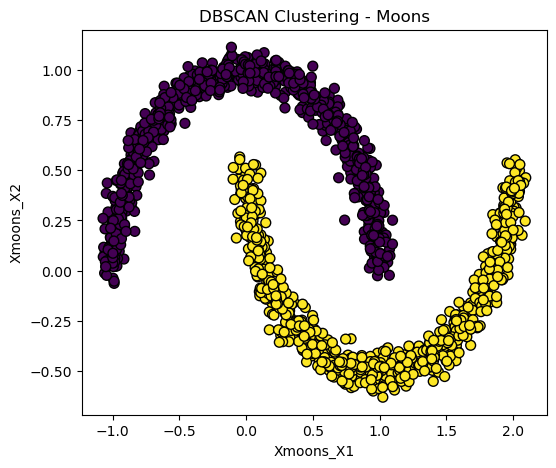

In [185]:
# Run DBSCAN on all datasets
for name, data in data.items():
    run_dbscan(name, data, eps, min_pts)

Problem 7

In [243]:
def extract_features(df):
    vectorizer = TfidfVectorizer(stop_words='english', max_features=1000)
    X = vectorizer.fit_transform(df['text']).toarray()
    return X


In [14]:
def run_dbscan(dataset_name, df, eps, min_pts): 
    X_scaled = extract_features(df)

    # Run DBSCAN
    model = DBSCAN(eps=eps, min_pts=min_pts)  
    model.fit(X_scaled)
    labels = model.labels
    num_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    num_noise = np.sum(labels == -1)

    print(f"\n--- {dataset_name} ---")
    print(f"Total Clusters: {num_clusters}")
    print(f"Total Noise Points: {num_noise}")

    if num_clusters > 1:
        print("Clustering performed successfully!")
    else:
        print("Only one cluster detected. No clear clustering.")
    if num_clusters > 1:
        # Silhouette Score
        score = silhouette_score(X_scaled, labels)
        print(f"Silhouette Score: {score:.4f}")
    else:
        print("Silhouette Score: N/A (only one cluster detected)")

In [253]:
from sklearn.datasets import fetch_20newsgroups
from sklearn.feature_extraction.text import TfidfVectorizer

newsgroups = fetch_20newsgroups(subset='all')
df_20ng = pd.DataFrame({'text': newsgroups.data})

run_dbscan("20NG", df_20ng, eps=0.3, min_pts=5)


--- 20NG ---
Total Clusters: 6
Total Noise Points: 0
Clustering performed successfully!
Silhouette Score: -0.0188


The 20 NG dataset has text data, and the distances in between points are less meaningful as it has a very high number of dimensions. Also, DBScan replied heavily on density, which is why it is not able to perform well on sparse datasets such as 20 NG.

Fashion Dataset

In [16]:
import tensorflow as tf
from tensorflow.keras.datasets import fashion_mnist
(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()
X = x_train.reshape((x_train.shape[0], -1))  # Flatten each 28x28 image into a vector

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [44]:
def run_dbscan(dataset_name, X_scaled, eps, min_pts):
    model = DBSCAN(eps=eps, min_pts=min_pts)
    model.fit(X_scaled)
    
    labels = model.labels

    num_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    num_noise = np.sum(labels == -1)

    print(f"\n--- {dataset_name} ---")
    print(f"Total Clusters: {num_clusters}")
    print(f"Total Noise Points: {num_noise}")

    if num_clusters > 1:
        score = silhouette_score(X_scaled, labels)
        print(f"Silhouette Score: {score:.4f}")
    else:
        print("Silhouette Score: N/A (only one cluster detected)")

In [54]:
run_dbscan("Fashion MNIST", X_scaled, eps=1, min_pts=8)


--- Fashion MNIST ---
Total Clusters: 2
Total Noise Points: 0
Silhouette Score: 0.4683


The Fashion Mind dataset contains clear separation between different groups, which is why these separations are dense. This makes it easier for dbscan to classify these clusters. This is suggested by the high score that we are getting for this dataset. 

Household dataset

In [6]:
df = pd.read_csv('household_power_consumption.txt', sep=';', parse_dates=[[0, 1]], na_values='?', low_memory=False)

df.rename(columns={'Date_Time': 'Datetime'}, inplace=True)

# Convert numeric columns to float
df.iloc[:, 1:] = df.iloc[:, 1:].astype(float)
df.dropna(inplace=True)

features = ['Global_active_power', 'Global_reactive_power', 'Voltage', 'Global_intensity']
X = df[features].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


/var/folders/lq/w3949rrj5b9gxkllt0m0pjcm0000gn/T/ipykernel_4887/1525455977.py:1: FutureWarning: Support for nested sequences for 'parse_dates' in pd.read_csv is deprecated. Combine the desired columns with pd.to_datetime after parsing instead.
  df = pd.read_csv('household_power_consumption.txt', sep=';', parse_dates=[[0, 1]], na_values='?', low_memory=False)
/var/folders/lq/w3949rrj5b9gxkllt0m0pjcm0000gn/T/ipykernel_4887/1525455977.py:1: UserWarning: Parsing dates in %d/%m/%Y %H:%M:%S format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df = pd.read_csv('household_power_consumption.txt', sep=';', parse_dates=[[0, 1]], na_values='?', low_memory=False)


In [8]:
X_scaled.shape

(2049280, 4)

In [38]:
X_scaled = X_scaled[:100000]

In [18]:
def run_dbscan(dataset_name, X_scaled, eps, min_pts):
    # Initialize and fit the custom DBSCAN model
    model = DBSCAN(eps=eps, min_pts=min_pts)
    model.fit(X_scaled)
    
    labels = model.labels
    
    num_clusters = len(set(labels)) - (1 if -1 in labels else 0)  # Ignore noise label (-1)
    num_noise = np.sum(labels == -1)

    print(f"\n--- {dataset_name} ---")
    print(f"Total Clusters: {num_clusters}")
    print(f"Total Noise Points: {num_noise}")

    if num_clusters > 1:
        score = silhouette_score(X_scaled, labels)
        print(f"Silhouette Score: {score:.4f}")
    else:
        print("Silhouette Score: N/A (only one cluster detected)")

In [42]:
run_dbscan("UCI Household Electric Power Consumption", X_scaled, eps=0.6, min_pts=8)


--- UCI Household Electric Power Consumption ---
Total Clusters: 6
Total Noise Points: 0
Silhouette Score: 0.3065


The dataset contains a few patterns that the dbscan can classify pretty well, but as this is time series data, it may have occasional fluctuations, which may make it harder for the dbscan to distinguish clustering. The score suggests that the clusters are a bit overlapped, as dbscan is not able to find the exact separation.

Problem 8

In [138]:
import numpy as np
import heapq
from sklearn.metrics import silhouette_score
from sklearn.datasets import make_moons

In [140]:
X, _ = make_moons(n_samples=500, noise=0.05, random_state=42)

In [142]:
# Compute cluster centroid
def compute_centroid(points):
    return np.mean(X[points], axis=0)

In [144]:
def merge_clusters(clusters, K, linkage="average"):
    active_clusters = set(clusters.keys())
    centroids = {i: X[i] for i in range(len(X))}  # Initialize centroids
    heap = []

    # compute initial pairwise distances
    for c1 in active_clusters:
        for c2 in active_clusters:
            if c1 < c2:
                dist = np.linalg.norm(centroids[c1] - centroids[c2])  # Euclidean distance
                heapq.heappush(heap, (dist, c1, c2))

    while len(active_clusters) > K:
        
        # find the closest valid clusters
        while heap:
            dist, c1, c2 = heapq.heappop(heap)
            if c1 in active_clusters and c2 in active_clusters:
                break  # Found valid pair
        else:
            print("Heap is empty too early! Stopping...")
            break

        # merge c1 and c2 into a new cluster
        new_cluster = max(active_clusters) + 1  # Assign new cluster ID
        clusters[new_cluster] = clusters[c1] + clusters[c2]  # Merge members
        centroids[new_cluster] = compute_centroid(clusters[new_cluster])  # Compute new centroid
        active_clusters.remove(c1)
        active_clusters.remove(c2)
        active_clusters.add(new_cluster)

        # update distances in heap
        for c in active_clusters:
            if c != new_cluster:
                d = np.linalg.norm(centroids[c] - centroids[new_cluster])  # Distance using centroid
                heapq.heappush(heap, (d, new_cluster, c))

    return clusters

In [146]:
# we run hierarchical clustering for K = {2, 5, 10}
for K in [2, 5, 10]:
    clusters = {i: [i] for i in range(len(X))}  # Reset clusters
    final_clusters = merge_clusters(clusters.copy(), K, linkage="average")

    # assign labels
    labels = np.zeros(len(X))
    for cluster_id, points in final_clusters.items():
        for point in points:
            labels[point] = cluster_id

    # silhouette score
    if len(set(labels)) > 1:  # Ensure at least 2 clusters
        score = silhouette_score(X, labels)
        print(f"Silhouette Score for K={K}: {score:.4f}")
    else:
        print(f"Silhouette Score for K={K} not valid (only one cluster detected).")

Silhouette Score for K=2: 0.4465
Silhouette Score for K=5: 0.3990
Silhouette Score for K=10: 0.4832


Based on the score, cutting the dendongram at k=10 will yield us with the best possible results, so we will use that for sepeartion.